# Customer Segmentation with RFM Analysis

## Overview
This project analyzes customer purchasing behavior using the RFM (Recency, Frequency, Monetary) method.

The analysis was performed using SQL and Python on the Online Retail dataset.

---

## Objectives
- Identify high-value customer groups
- Analyze customer distribution across segments
- Evaluate which customer groups contribute most to total revenue

---

## Tools
- SQL (DuckDB)
- Python
- pandas
- matplotlib

---

## Methodology

### RFM Metrics
- Recency: How recently the customer placed the last order
- Frequency: How frequently the customer placed orders
- Monetary: Total amount spent by the customer

### Customer Segments
Customers were categorized into the following groups:
- Best Customers
- At Risk High Value
- Active Low Value
- Recent Big Spenders
- Others

---

## Results

### Revenue Share by Customer Segment
![Revenue Share](revenue_share.png)

Best Customers contributed more than 75% of total revenue while representing only around 30% of all customers.

At Risk High Value customers generated the second-largest share of revenue and may require retention strategies.

---

### Customer Distribution Across RFM Segments
![Customer Distribution](customer_distribution.png)

The "Others" segment contained the largest number of customers but contributed relatively little revenue.

---

## Interpretation
The analysis suggests that Best Customers should be prioritized because they generate the majority of revenue.

At Risk High Value customers are also important because they contribute significantly to revenue despite not purchasing recently.

Recent Big Spenders may have the potential to become Best Customers in the future.

---

## Dataset
Online Retail Dataset:
https://www.kaggle.com/datasets

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
con = duckdb.connect()

In [5]:
import os
    
if not os.path.exists("online_retail.csv"):
        print("Please download the dataset from Kaggle and place it here.")
else:
    df = con.sql("""
        WITH clean AS(    
            SELECT CustomerID, InvoiceNo, Quantity * UnitPrice AS revenue, InvoiceDate
            FROM 'online_retail.csv'
            WHERE
            CustomerID IS NOT NULL
            AND InvoiceNo IS NOT NULL
            AND InvoiceDate IS NOT NULL
            AND Quantity > 0
            AND UnitPrice > 0
        ),
        customer AS(
            SELECT CustomerID, SUM(revenue) AS monetary, COUNT(DISTINCT InvoiceNo) AS frequency, MAX(InvoiceDate) AS final_order
            FROM clean
            GROUP BY CustomerID
        ),
        rfm AS(
            SELECT CustomerID, monetary, frequency, final_order, DATE_DIFF('day', final_order, MAX(final_order) OVER()) AS recency
            FROM customer
        ),
        category AS(
            SELECT CustomerID, monetary, frequency, final_order, recency,
                CASE 
                WHEN monetary >= MEDIAN(monetary) OVER() THEN 'high' 
                ELSE 'low' 
                END AS sales_category, 
                CASE 
                WHEN frequency >= MEDIAN(frequency) OVER() THEN 'frequent' 
                ELSE 'not_frequent' 
                END AS frequency_category, 
                CASE 
                WHEN recency <= MEDIAN(recency) OVER() THEN 'recent'
                ELSE 'not_recent'
                END AS recency_category
            FROM rfm
        ),
        segment AS(
            SELECT CustomerID, monetary, frequency, final_order, recency,
                CASE 
                WHEN sales_category = 'high' AND frequency_category = 'frequent' AND recency_category = 'recent' THEN 'Best Customers'
                WHEN sales_category = 'high' AND frequency_category = 'not_frequent' AND recency_category = 'recent' THEN 'Recent Big Spenders'
                WHEN sales_category = 'high' AND frequency_category = 'frequent' AND recency_category = 'not_recent' THEN 'At Risk High Value'
                WHEN sales_category = 'low' AND frequency_category = 'frequent' AND recency_category = 'recent' THEN 'Active Low Value'
                ELSE 'others'
                END AS customer_segment
            FROM category       
        ),
        final AS(
            SELECT customer_segment, COUNT(*) AS customers, 
                ROUND(AVG(monetary),2) AS average_sales,
                ROUND(AVG(frequency),2) AS average_frequency,
                ROUND(SUM(monetary), 2) AS total_sales,
                ROUND(SUM(monetary) * 100.0 / SUM(SUM(monetary)) OVER(), 2) AS sales_share
            FROM segment
            GROUP BY customer_segment
        )
        SELECT customer_segment, customers, average_sales, average_frequency, total_sales, sales_share, customers * 100.0 /SUM(customers) OVER() AS customers_share
        FROM final
        ORDER BY total_sales DESC
        LIMIT 30
        """).df()

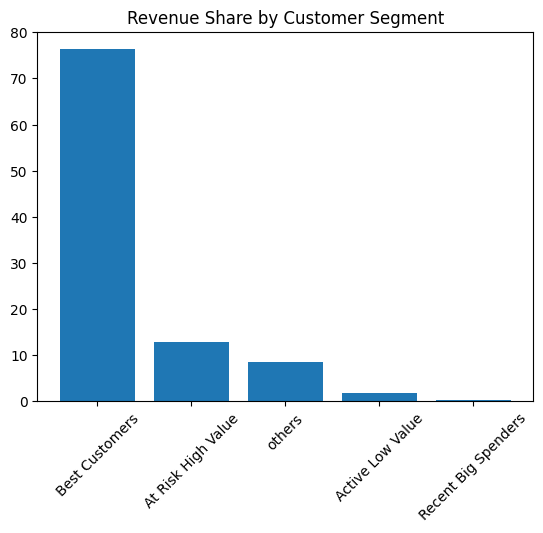

In [6]:
plt.bar(df["customer_segment"], df["sales_share"])
plt.xticks(rotation=45)
plt.title("Revenue Share by Customer Segment")
plt.savefig("revenue_share.png", bbox_inches='tight')

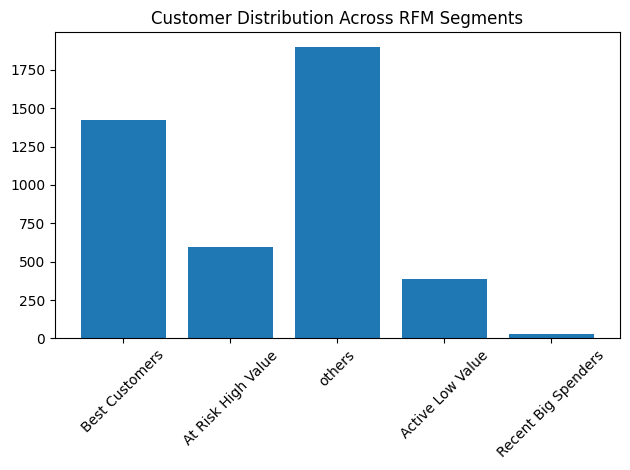

In [7]:
plt.bar(df["customer_segment"], df["customers"])
plt.xticks(rotation=45)
plt.title("Customer Distribution Across RFM Segments")
plt.tight_layout()
plt.savefig("customer_distribution.png",bbox_inches='tight')